# Linear Regression
Single feature linear regression problem.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
plt.style.use('dark_background')

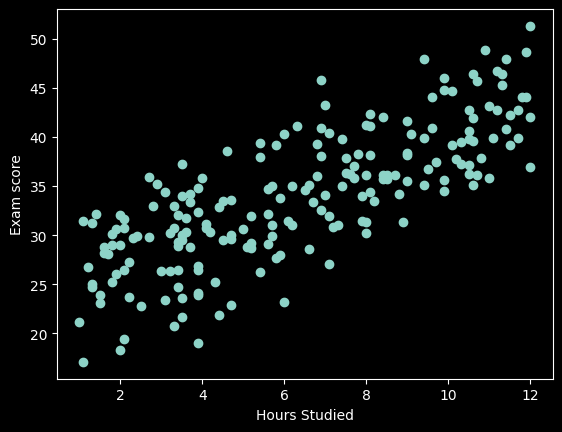

In [2]:
df = pd.read_csv("data/student_exam_scores.csv")

x = df["hours_studied"]
y = df["exam_score"]
m = x.size

plt.xlabel("Hours Studied")
plt.ylabel("Exam score")
plt.scatter(x, y)

x_max = np.max(x)
y_max = np.max(y)
x /= x_max
y /= y_max

In [3]:
def gradient(w, b):
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        y_pred = w * x[i] + b
        y_actual = y[i]
        delta_y = y_pred - y_actual

        dj_dw += delta_y * x[i]
        dj_db += delta_y
    
    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

In [4]:
def cost(w, b):
    c = 0
    
    for i in range(m):
        y_pred = w * x[i] + b
        y_actual = y[i]
        c += (y_pred - y_actual)**2

    c /= 2 * m
    return c

In [5]:
w = 0
b = 0
it = 10000
alpha = 0.01  # learning rate

for i in range(it):
    dj_dw, dj_db = gradient(w, b)
    w = w - alpha * dj_dw    
    b = b - alpha * dj_db

    c = cost(w, b)

    if i % (it / 10) == 0:
        print(f"cost={c:.3f}, w={w:.3f}, b={b:.3f}")

# Rescale
x *= x_max
y *= y_max

w_og = w * (y_max / x_max)
b_og = b * y_max

cost=0.222, w=0.004, b=0.007
cost=0.004, w=0.328, b=0.491
cost=0.003, w=0.351, b=0.478
cost=0.003, w=0.364, b=0.470
cost=0.003, w=0.372, b=0.466
cost=0.003, w=0.376, b=0.464
cost=0.003, w=0.379, b=0.462
cost=0.003, w=0.380, b=0.461
cost=0.003, w=0.381, b=0.461
cost=0.003, w=0.382, b=0.461


hours_studied=0, test_score=23.62893952672525
hours_studied=2, test_score=26.894023535158826
hours_studied=4, test_score=30.159107543592405
hours_studied=6, test_score=33.42419155202598
hours_studied=8, test_score=36.689275560459556
hours_studied=10, test_score=39.95435956889314
hours_studied=12, test_score=43.219443577326714
hours_studied=14, test_score=46.48452758576029
hours_studied=16, test_score=49.749611594193865
hours_studied=18, test_score=53.01469560262744


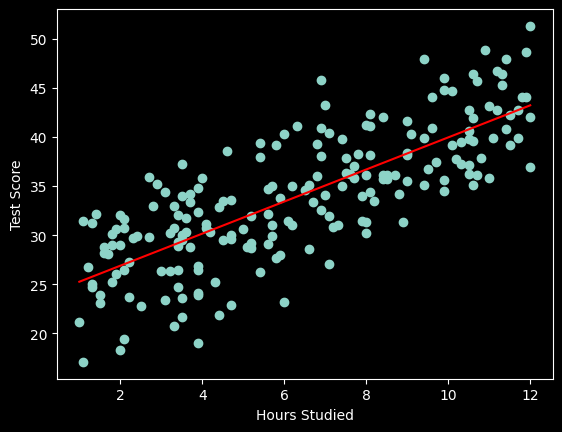

In [7]:
x_line = np.linspace(np.min(x), x_max)
y_line = w_og * x_line + b_og

plt.xlabel("Hours Studied")
plt.ylabel("Test Score")
plt.scatter(x, y)
plt.plot(x_line, y_line, c='r')

def get_test_score(hours_studied):
    """ The final trained model used for inference! """
    test_score = w_og * hours_studied + b_og
    print(f"hours_studied={hours_studied}, test_score={test_score}")

for i in range(0,20,2):
    get_test_score(i)


Why do you need to normalize the data?